In [3]:
!pip install numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [94]:
import collections
import glob
import csv
import math

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm

In [95]:
def load_group(group):
    points = collections.defaultdict(lambda: {})

    for filename in glob.glob("target/criterion/*/*/*/new/raw.csv"):
        with open(filename) as f:
            for record in csv.DictReader(f):
                if record["group"] == group:
                    function = record["function"]
                    size_x, prefix_x = record["value"].split("-")
                    _, size = size_x.split("_")
                    _, prefix = prefix_x.split("_")
                    
                    size = int(size)
                    prefix = int(prefix)
                    measured = float(record["sample_measured_value"]) / int(record["iteration_count"])
                    assert record["unit"] == "ns"

                    points[(size, prefix)][function] = measured

    return points

In [96]:
def speedup(group):
    for (size, prefix), m in load_group(group).items():
        if "vendored_std" in m and "partial_sort_1_0_0" in m:
            yield (size, prefix, m["vendored_std"] / m["partial_sort_1_0_0"])

In [149]:
def plot(group):
    data = list(speedup(group))
    sizes = np.array([d[0] for d in data])
    prefixes = np.array([d[1] for d in data])
    speedups = np.array([d[2] for d in data])
    
    sizes_vals = np.unique(sizes)
    prefixes_vals = np.unique(prefixes)

    Z = np.full((len(prefixes_vals), len(sizes_vals)), np.nan)

    for n, kf, s in data:
        i = np.where(prefixes_vals == kf)[0][0]
        j = np.where(sizes_vals == n)[0][0]
        Z[i, j] = s

    Z_log = np.log2(Z)

    plt.figure()
    plt.pcolormesh(
        sizes_vals,
        prefixes_vals,
        Z_log,
        cmap="RdYlGn_r",
        norm=TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)
        #norm=TwoSlopeNorm(vmin=0.5, vcenter=1.0, vmax=2.0)
    )
    
    plt.xscale("log")
    plt.gca().set_xlim([5, None])
    plt.gca().set_ylim([0, 20])
    plt.xlabel("slice length")
    plt.ylabel("prefix percent")
    cbar = plt.colorbar(label="speedup")
    cbar.set_ticks([-2, -1, 0, 1, 2])
    cbar.set_ticklabels(["0.25", "0.5", "1", "2", "4"])
    #plt.plot(range(1, 5000), [100 / x * (4 * math.log(x)) for x in range(1, 5000)], 'k-')
    plt.plot(range(1, 8000), [64 / x * 100 for x in range(1, 8000)], 'k--')
    plt.plot(range(1, 5000), [16 / x * 100 for x in range(1, 5000)], 'k--')
    plt.plot(range(1, 2000), [8 / x * 100 for x in range(1, 2000)], 'k--')
    plt.plot(range(1, 2000), [4 / x * 100 for x in range(1, 2000)], 'k--')
    plt.title(f"Speedup partial_sort_1_0_0 vs vendored_std: {group}")
    plt.show()

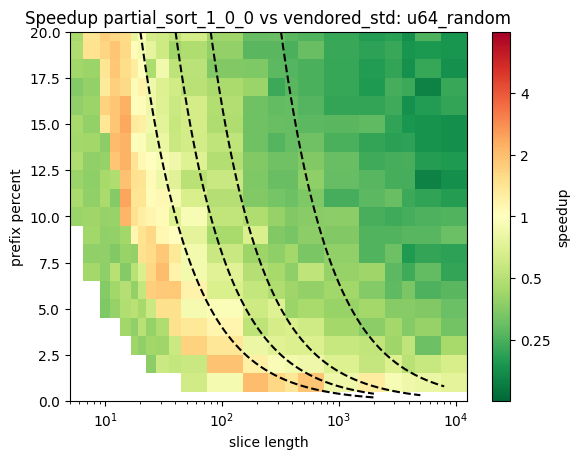

In [150]:
plot("u64_random")

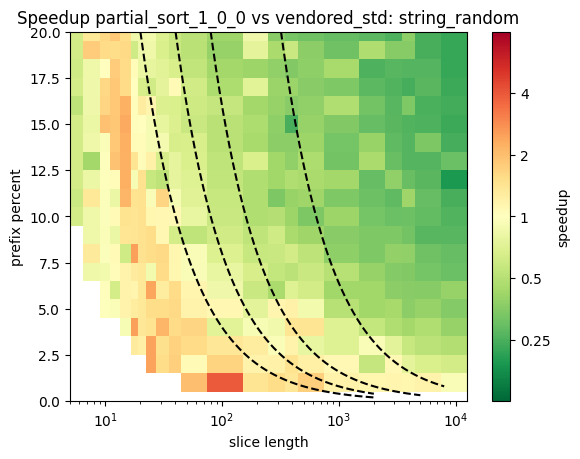

In [151]:
plot("string_random")

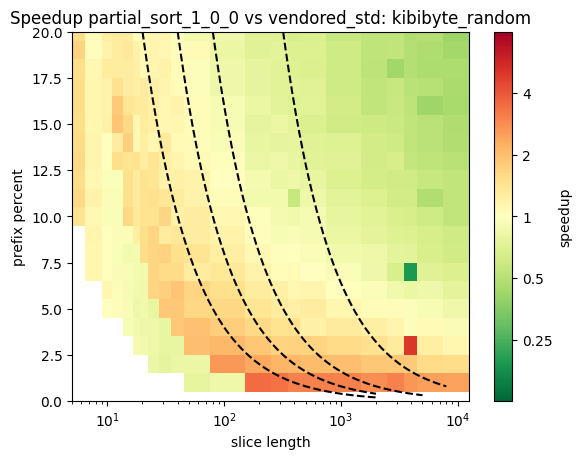

In [152]:
plot("kibibyte_random")

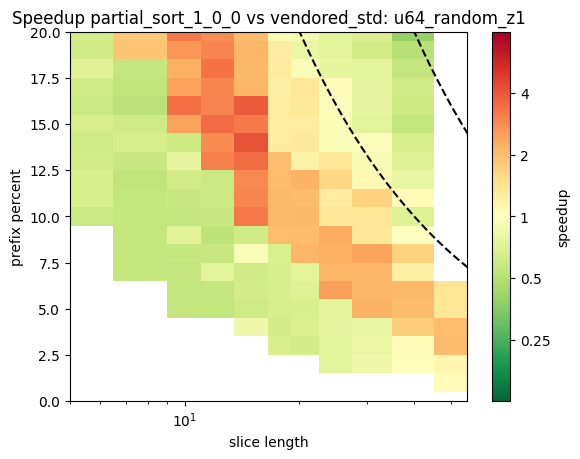

In [148]:
plot("u64_random_z1")